# 07 — Building the Faithfulness Dataset

This notebook walks through turning the two SQLite databases in `data/` into a single, tabular, one-row-per-item dataset, and visualizes it.

**Inputs**
- `data/annotations_prod.db` — 817 claim/evidence **items**, plus per-dimension **difficulty scores** (13 dimensions).
- `data/predictions.db` — repeated **LLM predictions** (entailed/refuted) for each item.

**Output** — one row per item (817 rows): item metadata + 13 difficulty-dimension scores + a summary of the LLM predictions.

**Eventual goal** — predict whether the LLM correctly judges an item, from its 13 difficulty scores. The two candidate targets this notebook builds are `pred_frac_correct` (continuous) and `pred_majority_correct` (binary).

> Decisions baked in here: the LLM target uses **run 1 only** (the unconditioned Haiku run, 5 trials per item), and all **13 dimensions are kept** even though `SNs` is scored on only 200 items (it is left blank elsewhere). The heavy lifting lives in `scripts/build_faithfulness_dataset.py`; this notebook calls those functions step by step so each stage is visible.

## 1. Setup

Resolve the repo root, import libraries, and import the processing helpers from `scripts/build_faithfulness_dataset.py`.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

# Resolve the repo root for both `jupyter notebook notebooks/...` and nbconvert from the repo root.
cwd = Path.cwd().resolve()
REPO_ROOT = cwd if (cwd / "scripts").exists() else cwd.parent
sys.path.insert(0, str(REPO_ROOT / "scripts"))

import build_faithfulness_dataset as bfd  # the processing module

ANNOTATIONS_DB = REPO_ROOT / "data" / "annotations_prod.db"
PREDICTIONS_DB = REPO_ROOT / "data" / "predictions.db"
PROCESSED_DIR = REPO_ROOT / "data" / "processed"
TARGET_RUN = 1  # unconditioned Haiku run, 5 trials per item

for _db in (ANNOTATIONS_DB, PREDICTIONS_DB):
    print(f"{'OK' if _db.exists() else 'MISSING'}  {_db}")

OK  /Users/everett/Documents/TheErdosInstitute/DataScienceBootCamp/Code/summer26-ai-faithfulness-in-scientific-reasoning/data/annotations_prod.db
OK  /Users/everett/Documents/TheErdosInstitute/DataScienceBootCamp/Code/summer26-ai-faithfulness-in-scientific-reasoning/data/predictions.db


## 2. Peek at the raw tables

Before combining anything, look at the three source tables in their natural ('long') shape.

In [2]:
item = bfd.read_table(ANNOTATIONS_DB, "item")
annotation = bfd.read_table(ANNOTATIONS_DB, "annotation")
prediction = bfd.read_table(PREDICTIONS_DB, "prediction")

print("item:      ", item.shape, "-> one row per claim/evidence pair")
print("annotation:", annotation.shape, "-> one row per (item, dimension, pass)")
print("prediction:", prediction.shape, "-> one row per (run, item, trial)")
item.head(3)

item:       (817, 8) -> one row per claim/evidence pair
annotation: (10013, 18) -> one row per (item, dimension, pass)
prediction: (13889, 20) -> one row per (run, item, trial)


,item_id,source,paperid,claim_type,vtype,image_path,claim,label
0,sciver_val_0,sciver,2409.12320v1,analytical,chart,/home/awndre/projects/Erdos/summer26-ai-scienc...,"Despite stable medians at 5, the 3.5% decline ...",1
1,sciver_val_1,sciver,2410.08207v1,analytical,chart,/home/awndre/projects/Erdos/summer26-ai-scienc...,The exponential λ schedule consistently yields...,1
2,sciver_val_2,sciver,2410.07073v2,analytical,chart,/home/awndre/projects/Erdos/summer26-ai-scienc...,The share of respondents 'not worried at all' ...,1


In [3]:
# A few annotation rows: each carries a score for ONE dimension of ONE item.
annotation[["item_id", "pass", "dim_code", "dim_name", "score", "parse_ok"]].head(5)

,item_id,pass,dim_code,dim_name,score,parse_ok
0,sciver_val_0,1,AS,Attention and Scan,2,1
1,sciver_val_0,1,QLq,Quantitative Reasoning,2,1
2,sciver_val_0,1,QLl,Logical Reasoning,3,1
3,sciver_val_0,1,MCr,Identifying Relevant Information,3,1
4,sciver_val_0,1,AT,Atypicality,3,1


In [4]:
# A few prediction rows: each is one LLM trial. `predicted` is the model's answer
# (1=entailed, 0=refuted) and `correct` is whether it matched the gold `label`.
prediction[prediction["run"] == TARGET_RUN][
    ["run", "item_id", "trial", "model", "predicted", "answer", "correct"]
].head(5)

,run,item_id,trial,model,predicted,answer,correct
0,1,sciver_val_0,1,claude-haiku-4-5,0,no,0
1,1,sciver_val_0,2,claude-haiku-4-5,0,no,0
2,1,sciver_val_1,1,claude-haiku-4-5,0,no,0
3,1,sciver_val_1,2,claude-haiku-4-5,1,yes,1
4,1,sciver_val_2,1,claude-haiku-4-5,1,yes,1


## 3. Dimension coverage

The 13 difficulty dimensions were collected across a few passes. Most are scored on all 817 items, but **`SNs` (Spatio-physical Reasoning) is scored on only 200** — it will be blank for the rest. This table is also written out as a small data dictionary.

In [5]:
dims = bfd.dimension_names(annotation)
dims

,dim_code,dim_name,items_scored
0,AS,Attention and Scan,817
1,AT,Atypicality,817
2,CL,"Conceptualisation, Learning, and Abstraction",817
3,GS,Gestalt and Shape Judgment,817
4,KNf,Formal Sciences,817
5,MA,Multi-Element Visual Aggregation,817
6,MCr,Identifying Relevant Information,817
7,MCu,Calibrating Knowns and Unknowns,817
8,QLl,Logical Reasoning,817
9,QLq,Quantitative Reasoning,817


## 4. Reshape annotations to one row per item (wide)

`build_annotation_wide` keeps a single score per (item, dimension) — preferring the latest pass when an item was scored more than once — then pivots so each dimension becomes its own `dim_*` column.

In [6]:
annotation_wide = bfd.build_annotation_wide(annotation)
print("annotation_wide:", annotation_wide.shape)
annotation_wide.head(3)

annotation_wide: (817, 14)


,item_id,dim_AS,dim_AT,dim_CL,dim_GS,dim_KNf,dim_MA,dim_MCr,dim_MCu,dim_QLl,dim_QLq,dim_SNs,dim_VL,dim_VO
0,sciver_test_1,3.0,4.0,0.0,1.0,1.0,3.0,2.0,3.0,2.0,2.0,NaN,3.0,2.0
1,sciver_test_101,2.0,3.0,2.0,0.0,2.0,1.0,3.0,3.0,3.0,2.0,NaN,2.0,2.0
2,sciver_test_103,3.0,3.0,1.0,5.0,2.0,2.0,3.0,4.0,3.0,2.0,NaN,2.0,2.0


## 5. Summarize the LLM predictions (target run)

`build_prediction_summary` collapses the repeated trials of the target run into one row per item: how many trials, how many correct, the fraction correct, and the majority vote.

In [7]:
prediction_summary = bfd.build_prediction_summary(prediction, TARGET_RUN)
print("prediction_summary:", prediction_summary.shape)
prediction_summary.head(3)

prediction_summary: (817, 9)


,item_id,pred_n_trials,pred_n_correct,pred_n_entailed,pred_frac_correct,pred_frac_entailed,pred_majority_correct,pred_majority_label,pred_unanimous
0,sciver_test_1,5,4,4,0.8,0.8,1,1,0
1,sciver_test_101,5,3,3,0.6,0.6,1,1,0
2,sciver_test_103,5,2,2,0.4,0.4,0,0,0


## 6. Combine into one table and save

Merge item metadata + dimension scores + prediction summary on `item_id`, giving one row per item. Then write parquet (for modeling) and CSV (for eyeballing) into `data/processed/`.

In [8]:
combined = bfd.build_combined(item, annotation_wide, prediction_summary)
print("combined:", combined.shape)
print("columns:", list(combined.columns))
combined.head(5)

combined: (817, 29)
columns: ['item_id', 'source', 'paperid', 'claim_type', 'vtype', 'image_path', 'claim', 'label', 'dim_AS', 'dim_AT', 'dim_CL', 'dim_GS', 'dim_KNf', 'dim_MA', 'dim_MCr', 'dim_MCu', 'dim_QLl', 'dim_QLq', 'dim_SNs', 'dim_VL', 'dim_VO', 'pred_n_trials', 'pred_n_correct', 'pred_n_entailed', 'pred_frac_correct', 'pred_frac_entailed', 'pred_majority_correct', 'pred_majority_label', 'pred_unanimous']


,item_id,source,paperid,claim_type,vtype,image_path,claim,label,dim_AS,dim_AT,dim_CL,dim_GS,dim_KNf,dim_MA,dim_MCr,dim_MCu,dim_QLl,dim_QLq,dim_SNs,dim_VL,dim_VO,pred_n_trials,pred_n_correct,pred_n_entailed,pred_frac_correct,pred_frac_entailed,pred_majority_correct,pred_majority_label,pred_unanimous
0,sciver_test_1,sciver,2409.06994v2,analytical,chart,/home/awndre/projects/Erdos/summer26-ai-scienc...,"In setting 10, increasing α from 0.0 to 0.3 re...",1,3.0,4.0,0.0,1.0,1.0,3.0,2.0,3.0,2.0,2.0,NaN,3.0,2.0,5,4,4,0.8,0.8,1,1,0
1,sciver_test_101,sciver,2410.02810v1,analytical,chart,/home/awndre/projects/Erdos/summer26-ai-scienc...,"At 30–40 steps, adding explicit state-tracking...",1,2.0,3.0,2.0,0.0,2.0,1.0,3.0,3.0,3.0,2.0,NaN,2.0,2.0,5,3,3,0.6,0.6,1,1,0
2,sciver_test_103,sciver,2410.11378v1,analytical,chart,/home/awndre/projects/Erdos/summer26-ai-scienc...,WPFed’s locality-sensitive hashing neighbor se...,1,3.0,3.0,1.0,5.0,2.0,2.0,3.0,4.0,3.0,2.0,NaN,2.0,2.0,5,2,2,0.4,0.4,0,0,0
3,sciver_test_105,sciver,2411.09556v1,analytical,chart,/home/awndre/projects/Erdos/summer26-ai-scienc...,"In 2TC, radiative losses lower electron temper...",1,2.0,4.0,1.0,0.0,2.0,1.0,2.0,3.0,3.0,3.0,NaN,2.0,2.0,5,1,1,0.2,0.2,0,0,0
4,sciver_test_106,sciver,2411.15583v1,analytical,chart,/home/awndre/projects/Erdos/summer26-ai-scienc...,The meta-analytic findings suggest that implic...,1,3.0,3.0,0.0,0.0,3.0,1.0,3.0,3.0,3.0,2.0,NaN,2.0,2.0,5,0,0,0.0,0.0,0,0,1


In [9]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
combined.to_parquet(PROCESSED_DIR / "faithfulness_dataset.parquet", index=False)
combined.to_csv(PROCESSED_DIR / "faithfulness_dataset.csv", index=False)
dims.to_csv(PROCESSED_DIR / "faithfulness_dataset_dimensions.csv", index=False)
print("wrote faithfulness_dataset.{parquet,csv} and _dimensions.csv to", PROCESSED_DIR)
print("(equivalently: python scripts/build_faithfulness_dataset.py)")

wrote faithfulness_dataset.{parquet,csv} and _dimensions.csv to /Users/everett/Documents/TheErdosInstitute/DataScienceBootCamp/Code/summer26-ai-faithfulness-in-scientific-reasoning/data/processed
(equivalently: python scripts/build_faithfulness_dataset.py)


## 7. Visualize the combined dataset

A first look at the label balance, the difficulty-score distributions, the LLM accuracy, and an early hint of whether difficulty relates to LLM correctness.

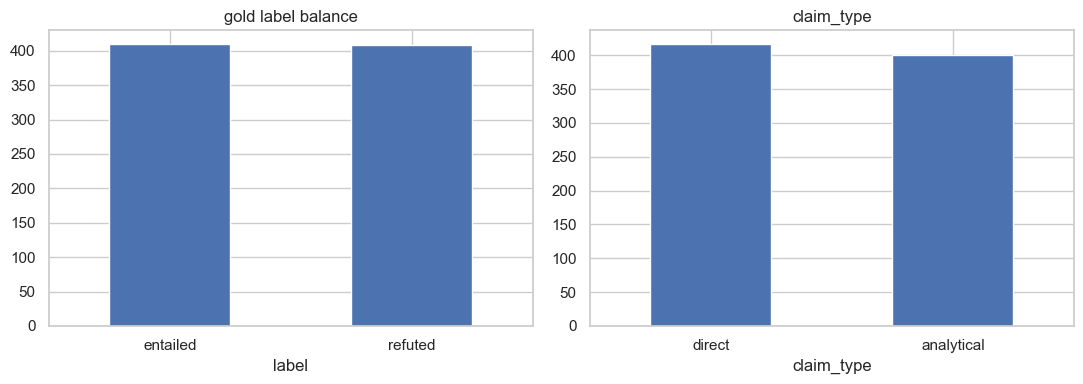

In [10]:
# Gold label balance and claim-type mix.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
combined["label"].map({0: "refuted", 1: "entailed"}).value_counts().plot.bar(
    ax=axes[0], title="gold label balance"
)
combined["claim_type"].value_counts().plot.bar(ax=axes[1], title="claim_type")
for ax in axes:
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

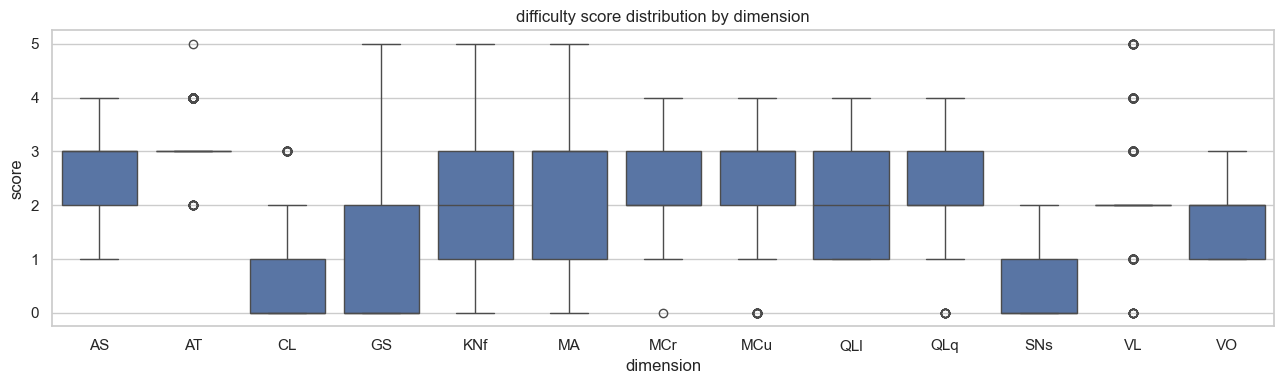

non-missing scores per dimension:
dim_AS     817
dim_AT     817
dim_CL     817
dim_GS     817
dim_KNf    817
dim_MA     817
dim_MCr    817
dim_MCu    817
dim_QLl    817
dim_QLq    817
dim_SNs    200
dim_VL     817
dim_VO     817


In [11]:
# Difficulty-score distributions across the 13 dimensions (note SNs is sparse).
dim_cols = [c for c in combined.columns if c.startswith("dim_")]
long = combined[dim_cols].melt(var_name="dimension", value_name="score").dropna()
long["dimension"] = long["dimension"].str.replace("dim_", "", regex=False)

plt.figure(figsize=(13, 4))
sns.boxplot(data=long, x="dimension", y="score", order=[c.replace("dim_", "") for c in dim_cols])
plt.title("difficulty score distribution by dimension")
plt.tight_layout()
plt.show()

print("non-missing scores per dimension:")
print(combined[dim_cols].notna().sum().to_string())

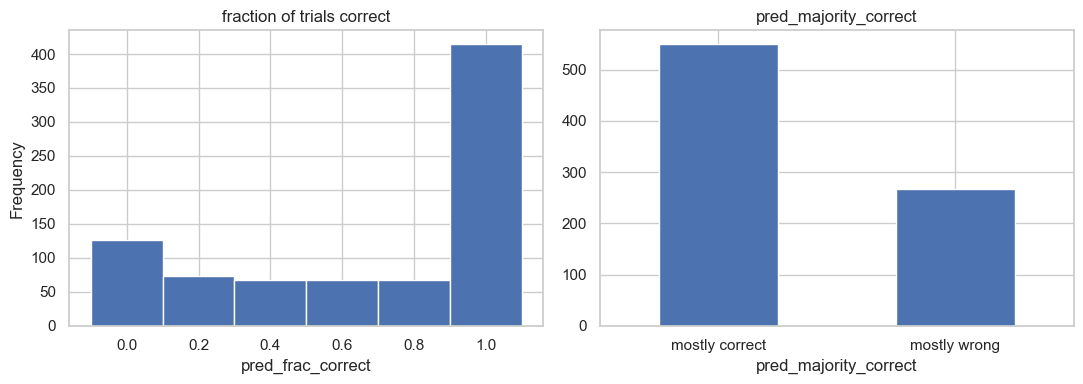

overall trial-level accuracy: 0.673
items the LLM got mostly correct: 549 / 817


In [12]:
# How often was the LLM correct? (target run, 5 trials per item)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
combined["pred_frac_correct"].plot.hist(
    bins=[-0.1, 0.1, 0.3, 0.5, 0.7, 0.9, 1.1], ax=axes[0], title="fraction of trials correct"
)
axes[0].set_xlabel("pred_frac_correct")
combined["pred_majority_correct"].map({0: "mostly wrong", 1: "mostly correct"}).value_counts().plot.bar(
    ax=axes[1], title="pred_majority_correct"
)
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print("overall trial-level accuracy:", round(combined["pred_n_correct"].sum() / combined["pred_n_trials"].sum(), 3))
print("items the LLM got mostly correct:", int(combined["pred_majority_correct"].sum()), "/", len(combined))

In [13]:
# Early signal check: does the LLM struggle more on harder items?
# Compare mean difficulty score per dimension, split by whether the LLM was mostly correct.
signal = combined.groupby("pred_majority_correct")[dim_cols].mean().T
signal.columns = ["mostly_wrong (0)", "mostly_correct (1)"]
signal["gap"] = signal["mostly_wrong (0)"] - signal["mostly_correct (1)"]
print("Mean dimension score by LLM correctness (positive gap = harder when LLM is wrong):")
print(signal.round(2).sort_values("gap", ascending=False).to_string())

# Target vs gold label, as a sanity check.
print("\npred_majority_correct vs gold label:")
print(pd.crosstab(combined["label"], combined["pred_majority_correct"]))

Mean dimension score by LLM correctness (positive gap = harder when LLM is wrong):
         mostly_wrong (0)  mostly_correct (1)   gap
dim_MCu              2.57                2.34  0.23
dim_AS               2.71                2.58  0.13
dim_MA               2.30                2.19  0.11
dim_SNs              0.34                0.22  0.11
dim_MCr              2.32                2.23  0.09
dim_VO               1.65                1.59  0.06
dim_VL               2.27                2.25  0.02
dim_AT               3.20                3.20 -0.00
dim_QLq              2.22                2.24 -0.02
dim_CL               0.46                0.51 -0.06
dim_KNf              1.93                2.06 -0.13
dim_QLl              1.87                2.00 -0.13
dim_GS               0.85                1.06 -0.21

pred_majority_correct vs gold label:
pred_majority_correct    0    1
label                          
0                       42  366
1                      226  183


## Next steps

The combined table is now model-ready. For the classifier (predicting whether the LLM is correct from the 13 difficulty scores):

- **Features (X):** the `dim_*` columns. Decide how to handle `dim_SNs` (impute, or drop the column) since it is blank for most items.
- **Target (y):** `pred_majority_correct` (binary) or `pred_frac_correct` (continuous).
- Start with logistic regression on the 12 complete dimensions, then add metadata (`claim_type`, `vtype`) and revisit `SNs`.